In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv("titanic_toy.csv")

In [4]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [5]:
x = df.drop(columns=["Survived"])
y = df["Survived"]

In [6]:
x

,Age,Fare,Family
0,22.0,7.2500,1
1,38.0,71.2833,1
2,26.0,7.9250,0
3,35.0,53.1000,1
4,35.0,8.0500,0
...,...,...,...
886,27.0,13.0000,0
887,19.0,30.0000,0
888,NaN,23.4500,3
889,26.0,NaN,0


In [7]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [9]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [10]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [11]:
X_train.shape

(712, 3)

In [13]:
X_train["Age_999"] = X_train["Age"].fillna(999)
X_train["Age_minus1"] = X_train["Age"].fillna(-1)

X_train['Fare_99'] = X_train['Fare'].fillna(99)
X_train['Fare_minus1'] = X_train['Fare'].fillna(-1)

In [15]:
print("Orginal Varience of Age ",X_train["Age"].var())
print("Age Varience of after arbitrary 999 imputation ",X_train["Age_999"].var())
print("Age Varience of after -1 imputation ",X_train["Age_minus1"].var())

print("Orginal Varience of Fare ",X_train["Fare"].var())
print("Fare Varience of after arbitrary 99 imputation ",X_train["Fare_99"].var())
print("Fare Varience of after -1 imputation ",X_train["Fare_minus1"].var())

Orginal Varience of Age  204.3495133904614
Age Varience of after arbitrary 999 imputation  155054.41209691283
Age Varience of after -1 imputation  318.0896202624484
Orginal Varience of Fare  2448.197913706318
Fare Varience of after arbitrary 99 imputation  2536.0773428319685
Fare Varience of after -1 imputation  2378.5676784883503


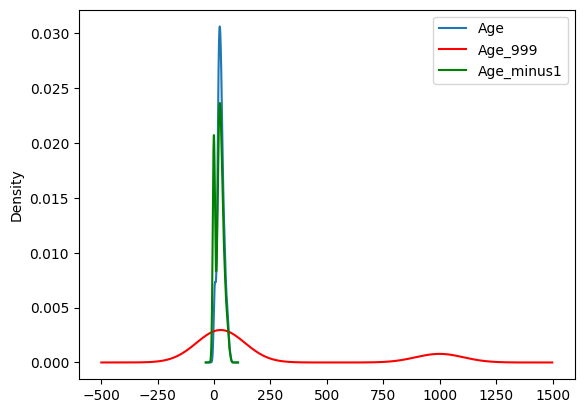

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Age'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['Age_999'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['Age_minus1'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

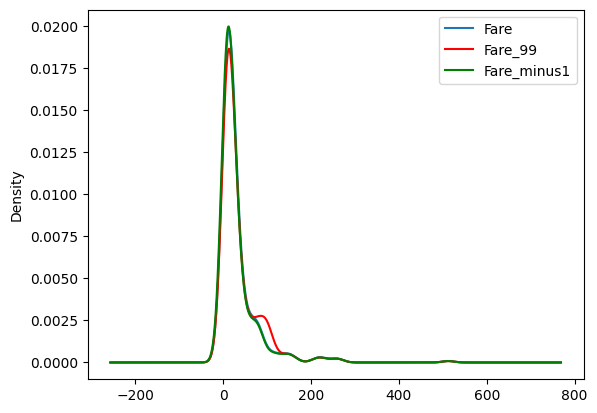

In [18]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Fare'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['Fare_99'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['Fare_minus1'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [19]:
X_train.cov()

,Age,Fare,Family,Age_999,Age_-1,Fare_99,Fare_minus1,Age_minus1
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,73.268412,63.321188,204.349513
Fare,70.719262,2448.197914,17.258917,-2146.736242,125.558364,2448.197914,2448.197914,125.558364
Family,-6.498901,17.258917,2.735252,-36.529656,-4.149246,16.051452,16.553989,-4.149246
Age_999,204.349513,-2146.736242,-36.529656,155054.412097,-4758.161980,-2167.022698,-1972.721263,-4758.161980
Age_-1,204.349513,125.558364,-4.149246,-4758.161980,318.089620,128.692715,114.394141,318.089620
Fare_99,73.268412,2448.197914,16.051452,-2167.022698,128.692715,2536.077343,2216.958409,128.692715
Fare_minus1,63.321188,2448.197914,16.553989,-1972.721263,114.394141,2216.958409,2378.567678,114.394141
Age_minus1,204.349513,125.558364,-4.149246,-4758.161980,318.089620,128.692715,114.394141,318.089620


In [21]:
X_train.corr()

,Age,Fare,Family,Age_999,Age_-1,Fare_99,Fare_minus1,Age_minus1
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.095527,0.084585,1.000000
Fare,0.092644,1.000000,0.208268,-0.109742,0.142022,1.000000,1.000000,0.142022
Family,-0.299113,0.208268,1.000000,-0.056093,-0.140668,0.192723,0.205233,-0.140668
Age_999,1.000000,-0.109742,-0.056093,1.000000,-0.677520,-0.109280,-0.102723,-0.677520
Age_-1,1.000000,0.142022,-0.140668,-0.677520,1.000000,0.143284,0.131514,1.000000
Fare_99,0.095527,1.000000,0.192723,-0.109280,0.143284,1.000000,0.902648,0.143284
Fare_minus1,0.084585,1.000000,0.205233,-0.102723,0.131514,0.902648,1.000000,0.131514
Age_minus1,1.000000,0.142022,-0.140668,-0.677520,1.000000,0.143284,0.131514,1.000000


In [22]:
X_train.var()

Age               204.349513
Fare             2448.197914
Family              2.735252
Age_999        155054.412097
Age_-1            318.089620
Fare_99          2536.077343
Fare_minus1      2378.567678
Age_minus1        318.089620
dtype: float64

In [32]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [33]:
imputer1 = SimpleImputer(strategy="constant",fill_value=99)
imputer2 = SimpleImputer(strategy="constant",fill_value=999)

In [34]:
trf1 = ColumnTransformer([
    ("imputer1",imputer1,["Age"]),
    ("imputer2",imputer2,["Fare"])
],remainder="passthrough")

In [35]:
trf1

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'constant'
,fill_value,99


In [36]:
trf1.fit(X_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'constant'
,fill_value,99


In [37]:
trf1.named_transformers_['imputer1'].statistics_

array([99.])

In [38]:
trf1.named_transformers_['imputer2'].statistics_

array([999.])

In [39]:
X_train = trf1.transform(X_train)
X_test = trf1.transform(X_test)

In [40]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 99.    , 221.7792,   0.    ],
       [ 99.    ,  25.925 ,   0.    ]], shape=(712, 3))

In [41]:
X_test

array([[4.200000e+01, 2.628750e+01, 0.000000e+00],
       [2.100000e+01, 8.050000e+00, 0.000000e+00],
       [2.400000e+01, 6.500000e+01, 3.000000e+00],
       [2.800000e+01, 5.649580e+01, 0.000000e+00],
       [1.700000e+01, 7.925000e+00, 6.000000e+00],
       [3.000000e+01, 7.895800e+00, 0.000000e+00],
       [8.000000e+01, 3.000000e+01, 0.000000e+00],
       [2.500000e+01, 7.250000e+00, 0.000000e+00],
       [5.000000e+01, 1.336500e+02, 2.000000e+00],
       [2.500000e+01, 2.600000e+01, 1.000000e+00],
       [3.500000e+01, 2.600000e+01, 0.000000e+00],
       [3.500000e+01, 9.000000e+01, 1.000000e+00],
       [5.500000e+01, 1.600000e+01, 0.000000e+00],
       [9.900000e+01, 5.649580e+01, 0.000000e+00],
       [9.900000e+01, 5.649580e+01, 0.000000e+00],
       [1.900000e+01, 7.854200e+00, 1.000000e+00],
       [9.900000e+01, 1.524580e+01, 2.000000e+00],
       [4.900000e+01, 0.000000e+00, 0.000000e+00],
       [1.800000e+01, 9.990000e+02, 1.000000e+00],
       [6.500000e+01, 7.750000e